In [1]:
import pandas as pd
import os
import kagglehub
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

D:\Anaconda\envs\New_env\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.metrics import r2_score

# Часть 1: Парная регрессия

In [3]:
brain_path = kagglehub.dataset_download("saarthaksangam/headbrain")

print("Path to dataset files:", brain_path)

print("Файлы в папке brain:")
print(os.listdir(brain_path))

Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\saarthaksangam\headbrain\versions\1
Файлы в папке brain:
['headbrain.csv']


In [4]:
brain = pd.read_csv(os.path.join(brain_path, 'headbrain.csv'))
print(brain.head())
print("="*50)
print(f"Размерность: {brain.shape}")
print(brain.dtypes)

   Gender  Age Range  Head Size(cm^3)  Brain Weight(grams)
0       1          1             4512                 1530
1       1          1             3738                 1297
2       1          1             4261                 1335
3       1          1             3777                 1282
4       1          1             4177                 1590
Размерность: (237, 4)
Gender                 int64
Age Range              int64
Head Size(cm^3)        int64
Brain Weight(grams)    int64
dtype: object


In [5]:
print(f"\nВсего пропусков: {brain.isnull().sum().sum()}")
total_duplicates = brain.duplicated().sum()
print(f"Полных дубликатов brain: {total_duplicates}")


Всего пропусков: 0
Полных дубликатов brain: 0


Выбор столбцов для регрессии

In [6]:
brain = brain.rename(columns={
    'Head Size(cm^3)': 'head_size',
    'Brain Weight(grams)': 'brain_weight'
})

X = brain[['head_size']]
y = brain['brain_weight']

Разделение данных на train и test

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Обучение модели

In [8]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.26]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['head_size']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,328.6
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [9]:
slope = model.coef_[0]

intercept = model.intercept_

print("ПАРАМЕТРЫ МОДЕЛИ")
print(f"Коэффициент наклона (slope):    {slope:.4f}")
print(f"Свободный член (intercept):     {intercept:.4f}")
print(f"\nУравнение регрессии:")
print(f"brain_weight = {slope:.4f} * head_size + {intercept:.4f}")

ПАРАМЕТРЫ МОДЕЛИ
Коэффициент наклона (slope):    0.2619
Свободный член (intercept):     328.6014

Уравнение регрессии:
brain_weight = 0.2619 * head_size + 328.6014


D:\Anaconda\envs\New_env\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


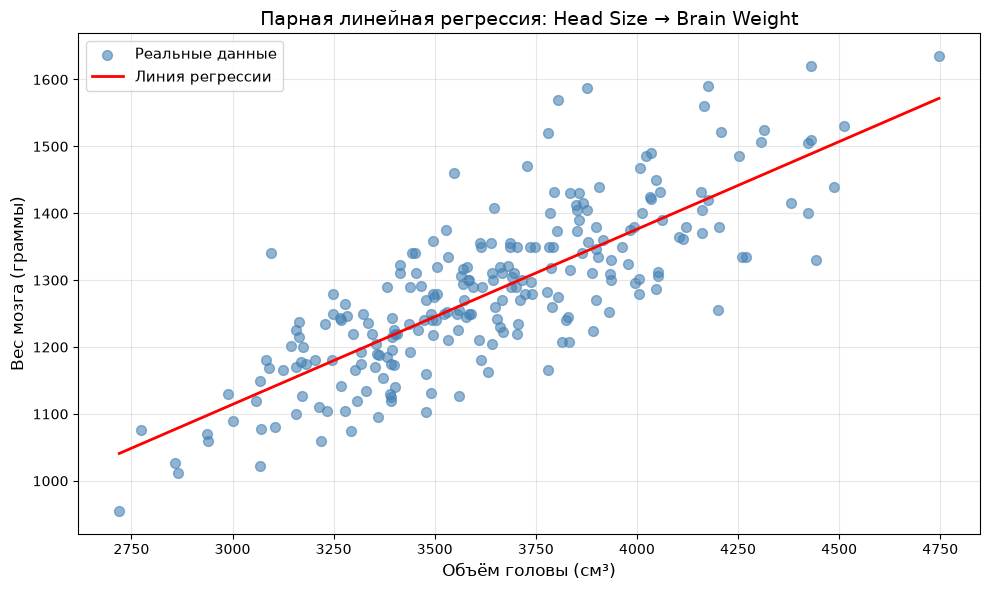

In [10]:
plt.figure(figsize=(10, 6))

# Исходные данные (все, не только train)
plt.scatter(brain['head_size'], brain['brain_weight'], 
            color='steelblue', alpha=0.6, label='Реальные данные', s=50)

# Линия регрессии
# Создаём 100 точек от min до max head_size
x_line = np.linspace(brain['head_size'].min(), brain['head_size'].max(), 100).reshape(-1, 1)
y_line = model.predict(x_line)

plt.plot(x_line, y_line, color='red', linewidth=2, label='Линия регрессии')

plt.title('Парная линейная регрессия: Head Size → Brain Weight', fontsize=14)
plt.xlabel('Объём головы (см³)', fontsize=12)
plt.ylabel('Вес мозга (граммы)', fontsize=12)
plt.legend(fontsize=11)
plt.grid(alpha=0.3)

plt.tight_layout()
plt.show()

In [11]:
y_pred = model.predict(X_test)
r2 = r2_score(y_test, y_pred)
print(f"R² = {r2:.4f}")

R² = 0.7149


Модель попадает 71% вариации веса мозга через объём головы. Остальные 29% — это индивидуальные различия, погрешности измерения и другие факторы (пол, возраст, генетика).

# Часть 2: Множественная регрессия

In [12]:
house_path = kagglehub.dataset_download("pranavshinde36/india-house-rent-prediction")

print("Path to dataset files:", house_path)

print("Файлы в папке house:")
print(os.listdir(house_path))

100%|██████████| 171k/171k [00:00<00:00, 786kB/s]

Extracting files...
Path to dataset files: C:\Users\Asus\.cache\kagglehub\datasets\pranavshinde36\india-house-rent-prediction\versions\1
Файлы в папке house:
['data.csv']


In [13]:
house = pd.read_csv(os.path.join(house_path, 'data.csv'))
print(house.head())
print("="*50)
print(f"Размерность: {house.shape}")
print(house.dtypes)

                                          house_type       locality    city  \
0  2 BHK Flat for Rent in Oberoi Woods, Goregaon ...  Goregaon East  Mumbai   
1  1 BHK Flat for Rent in Sapphire Lakeside, Powa...          Powai  Mumbai   
2               1 BHK House for Rent in Mundhwa Pune        Mundhwa    Pune   
3              2 BHK Flat for Rent in Hingna, Nagpur         Hingna  Nagpur   
4  1 BHK Flat for Rent in Unique Star Harsh Vihar...      Mira Road  Mumbai   

     area  beds  bathrooms  balconies      furnishing  area_rate      rent  
0   897.0     2          2          0  Semi-Furnished      134.0  120000.0  
1   490.0     1          1          0  Semi-Furnished       82.0   40000.0  
2   550.0     1          1          0     Unfurnished       22.0   12000.0  
3  1000.0     2          2          0     Unfurnished        8.0    8000.0  
4   595.0     1          1          0     Unfurnished       25.0   15000.0  
Размерность: (7691, 10)
house_type        str
locality         

In [16]:
print(f"\nВсего пропусков: {house.isnull().sum().sum()}")
total_duplicates_ = house.duplicated().sum()
print(f"Полных дубликатов house: {total_duplicates_}")


Всего пропусков: 0
Полных дубликатов house: 0


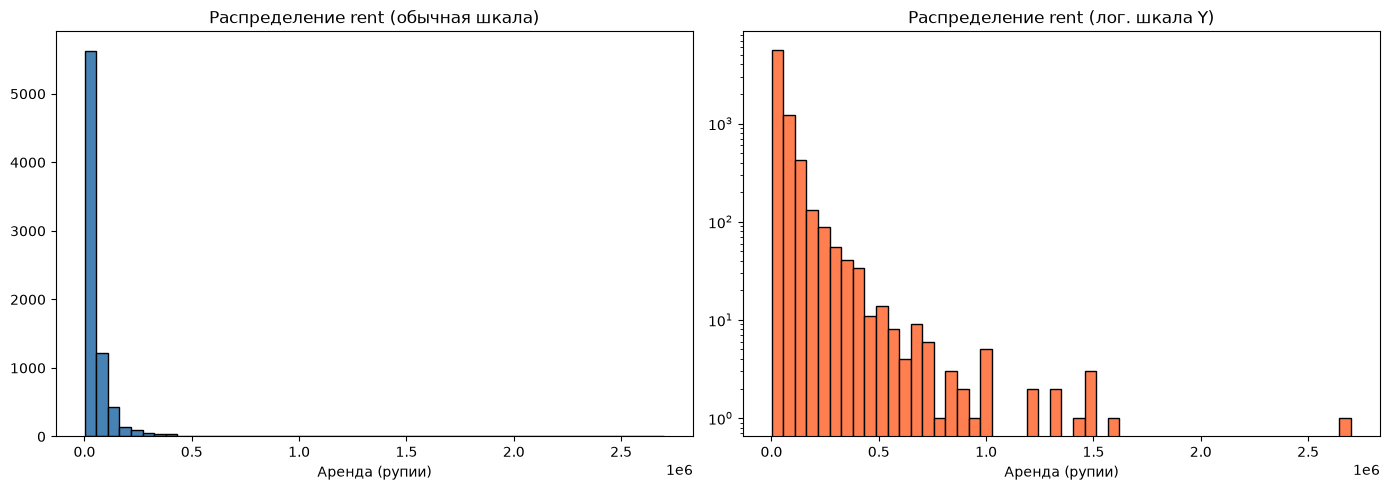

Статистика rent:
count    7.691000e+03
mean     5.479508e+04
std      9.742006e+04
min      1.000000e+03
25%      1.500000e+04
50%      2.800000e+04
75%      5.700000e+04
max      2.700000e+06
Name: rent, dtype: float64

Медиана: 28000.0
Среднее: 54795.08282408009
Максимум: 2700000.0


In [20]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Обычная шкала
axes[0].hist(house['rent'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Распределение rent (обычная шкала)')
axes[0].set_xlabel('Аренда (рупии)')

# Логарифмическая шкала
axes[1].hist(house['rent'], bins=50, color='coral', edgecolor='black', log=True)
axes[1].set_title('Распределение rent (лог. шкала Y)')
axes[1].set_xlabel('Аренда (рупии)')

plt.tight_layout()
plt.show()

print("Статистика rent:")
print(house['rent'].describe())
print(f"\nМедиана: {house['rent'].median()}")
print(f"Среднее: {house['rent'].mean()}")
print(f"Максимум: {house['rent'].max()}")

In [ ]:
В датасете присутсвуют очень дорогие и очень дешевые квартиры, это выбросы, 
прологарифмируем целевую переменную чтобы снизить эту разницу и добиться большей точности модели.

In [18]:
house['log_rent'] = np.log1p(house['rent'])

print("Статистика log(rent):")
print(house['log_rent'].describe())

Статистика log(rent):
count    7691.000000
mean       10.334956
std         0.988415
min         6.908755
25%         9.615872
50%        10.239996
75%        10.950824
max        14.808763
Name: log_rent, dtype: float64


Выбираем признаки

In [22]:
house[['area', 'beds', 'bathrooms', 'balconies', 'log_rent']].corr()['log_rent'].sort_values()

balconies    0.317408
area         0.458206
beds         0.660353
bathrooms    0.716801
log_rent     1.000000
Name: log_rent, dtype: float64

In [27]:
y = house['log_rent']

# Функция для эксперимента
def run_experiment(features, name):
    X = house[features]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42
    )

    model = LinearRegression()
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    return {
        'Experiment': name,
        'Features': ', '.join(features),
        'N_features': len(features),
        'Slope(s)': [round(c, 4) for c in model.coef_],
        'Intercept': round(model.intercept_, 2),
        'MAE': round(mean_absolute_error(y_test, y_pred), 4),
        'MSE': round(mean_squared_error(y_test, y_pred), 4),
        'RMSE': round(np.sqrt(mean_squared_error(y_test, y_pred)), 4),
        'R2': round(r2_score(y_test, y_pred), 4),
        'model': model,
        'y_test': y_test,
        'y_pred': y_pred,
    }

# Три эксперимента
results = [
    run_experiment(['bathrooms'], 'A: 1 feature'),
    run_experiment(['bathrooms', 'beds'], 'B: 2 features'),
    run_experiment(['bathrooms', 'beds', 'area', 'balconies'], 'C: all features')
]

# Сводная таблица по экспериментам
df_results = pd.DataFrame([{k: v for k, v in r.items()
                            if k not in ('model', 'y_test', 'y_pred')} for r in results])
print(df_results.to_string(index=False))

     Experiment                         Features  N_features                         Slope(s)  Intercept    MAE    MSE   RMSE     R2
   A: 1 feature                        bathrooms           1                         [0.6902]       8.86 0.5252 0.4479 0.6693 0.5426
  B: 2 features                  bathrooms, beds           2                  [0.534, 0.1894]       8.78 0.5229 0.4423 0.6650 0.5484
C: all features bathrooms, beds, area, balconies           4 [0.509, 0.1724, 0.0001, -0.0098]       8.80 0.5209 0.4372 0.6612 0.5536


In [28]:
# Считаем метрики для Head Brain
mae_hb  = mean_absolute_error(y_test, y_pred)
mse_hb  = mean_squared_error(y_test, y_pred)
rmse_hb = np.sqrt(mse_hb)
r2_hb   = r2_score(y_test, y_pred)

summary_rows = [
    {
        'Dataset': 'Head Brain',
        'Task': 'Simple Linear Regression',
        'Features': 'head_size',
        'N_features': 1,
        'MAE': round(mae_hb, 4),
        'MSE': round(mse_hb, 4),
        'RMSE': round(rmse_hb, 4),
        'R2': round(r2_hb, 4),
    }
]

# Добавляем все эксперименты множественной регрессии
for r in results:
    summary_rows.append({
        'Dataset': 'India House Rent',
        'Task': r['Experiment'],
        'Features': r['Features'],
        'N_features': r['N_features'],
        'MAE': r['MAE'],
        'MSE': r['MSE'],
        'RMSE': r['RMSE'],
        'R2': r['R2'],
    })

summary = pd.DataFrame(summary_rows)
print(summary.to_string(index=False))

         Dataset                     Task                         Features  N_features     MAE       MSE    RMSE     R2
      Head Brain Simple Linear Regression                        head_size           1 54.6260 4672.0435 68.3523 0.7149
India House Rent             A: 1 feature                        bathrooms           1  0.5252    0.4479  0.6693 0.5426
India House Rent            B: 2 features                  bathrooms, beds           2  0.5229    0.4423  0.6650 0.5484
India House Rent          C: all features bathrooms, beds, area, balconies           4  0.5209    0.4372  0.6612 0.5536


На датасете Head Brain модель парной регрессии показала R² = 0.71, подтвердив сильную линейную зависимость веса мозга от объёма головы. На датасете India House Rent были проведены три эксперимента с разными комбинациями признаков, результаты показали устойчивую закономерность: чем больше информативных признаков, тем выше качество модели (R² вырос при переходе от одного признака к четырем). Метрики считались как в логарифмической шкале (в которой обучалась модель), что наглядно продемонстрировало влияние нелинейного преобразования целевой переменной на итоговое качество.